## Librerías.

In [9]:
import sys
import os
import joblib
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers, regularizers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.models import load_model, Model
from tensorflow.keras import optimizers

import matplotlib.pyplot as plt
import numpy as np
from sklearn.svm import SVC

In [10]:
from google.colab import drive
drive.mount('/content/drive')
project_path = '/content/drive/MyDrive/Redes neuronales/Tarea 7. Reconocimiento facial'
if project_path not in sys.path:
    sys.path.append(project_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Fine tunning.

In [11]:
# Configuramos direcciones.
data_dir = os.path.join(project_path, 'data/binary')

In [7]:
# Generadores.
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2)

# Generador de entrenamiento.
train_gen = datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=8,
    class_mode='binary',
    subset='training',
    shuffle=True)

# Generador de validación.
valid_gen = datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=8,
    class_mode='binary',
    subset='validation',
    shuffle=False)

Found 120 images belonging to 2 classes.
Found 29 images belonging to 2 classes.


In [22]:
# Cargamos modelo.
modelo_crudo = os.path.join(project_path, 'models/mi_reconocedor_p1.h5')
model = load_model(modelo_crudo)

# Buscamos el extractor de características.
feature_extractor = None
for layer in model.layers:
    if isinstance(layer, tf.keras.Sequential):
        feature_extractor = layer
        break

if feature_extractor:
    print(f"Extractor base encontrado: {feature_extractor.name}")
    feature_extractor.trainable = True

    # Entrenamos solo las últimas capas.
    capas_a_entrenar = 2
    for layer in feature_extractor.layers[:-capas_a_entrenar]:
        layer.trainable = False

Extractor base encontrado: sequential


In [24]:
# Recompilamos.
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy'])

ruta_final_refinado = os.path.join(project_path, 'models/mi_reconocedor_refinado_2.h5')

checkpoint_fino = ModelCheckpoint(
    filepath=ruta_final_refinado,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1)

early_stop_fino = EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True)

In [25]:
# Entrenamos.
history_fine = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=100,
    callbacks=[checkpoint_fino, early_stop_fino])

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.7584 - loss: 0.7735
Epoch 1: val_accuracy improved from -inf to 0.68966, saving model to /content/drive/MyDrive/Redes neuronales/Tarea 7. Reconocimiento facial/models/mi_reconocedor_refinado_2.h5


15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 325ms/step - accuracy: 0.7574 - loss: 0.7735 - val_accuracy: 0.6897 - val_loss: 0.7813
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.7719 - loss: 0.7709
Epoch 2: val_accuracy did not improve from 0.68966
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 254ms/step - accuracy: 0.7711 - loss: 0.7710 - val_accuracy: 0.6552 - val_loss: 0.7809
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.7860 - loss: 0.7701
Epoch 3: val_accuracy improved from 0.68966 to 0.75862, saving model to /content/drive/MyDrive/Redes neuronales/Tarea 7. Reconocimiento facial/models/mi_reconocedor_refinado_2.h5


15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 327ms/step - accuracy: 0.7843 - loss: 0.7702 - val_accuracy: 0.7586 - val_loss: 0.7805
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.8105 - loss: 0.7733
Epoch 4: val_accuracy improved from 0.75862 to 0.79310, saving model to /content/drive/MyDrive/Redes neuronales/Tarea 7. Reconocimiento facial/models/mi_reconocedor_refinado_2.h5


15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 256ms/step - accuracy: 0.8114 - loss: 0.7732 - val_accuracy: 0.7931 - val_loss: 0.7805
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.7888 - loss: 0.7682
Epoch 5: val_accuracy did not improve from 0.79310
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 247ms/step - accuracy: 0.7859 - loss: 0.7685 - val_accuracy: 0.7586 - val_loss: 0.7802
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.7831 - loss: 0.7733
Epoch 6: val_accuracy did not improve from 0.79310
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 335ms/step - accuracy: 0.7826 - loss: 0.7732 - val_accuracy: 0.7241 - val_loss: 0.7799
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.6830 - loss: 0.7732
Epoch 7: val_accuracy did not improve from 0.79310
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 249ms/step - accuracy: 0.6825 - loss: 0.7732 - val_accuracy: 0.7241 - val_loss: 0.7797
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.7772 - loss: 0.7727
Epoch 8: val_accuracy did not i

In [26]:
def graficar_entrenamiento(historia):
    acc = historia.history['accuracy']
    val_acc = historia.history['val_accuracy']
    loss = historia.history['loss']
    val_loss = historia.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))

    # Presición.
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', color='green')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='red')
    plt.legend(loc='lower right')
    plt.title('Precisión (Accuracy)')
    plt.grid(True)
    plt.xlabel('Épocas')
    plt.ylabel('Precisión')

    # Costo.
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', color='green')
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='red')
    plt.legend(loc='upper right')
    plt.title('Costo (Loss)')
    plt.grid(True)
    plt.xlabel('Épocas')
    plt.ylabel('Loss')

    plt.show()

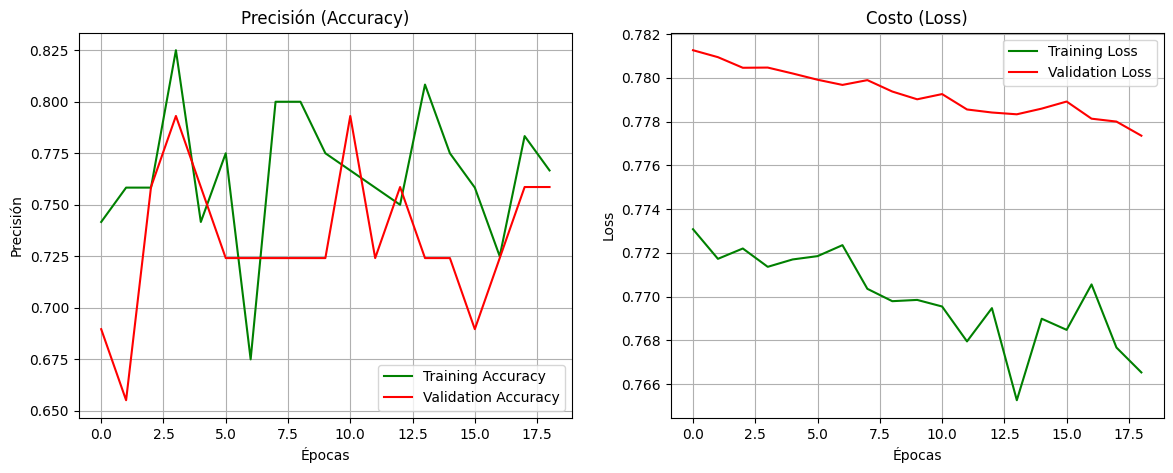

In [27]:
# Graficamos.
graficar_entrenamiento(history_fine)

## SVM para ayudar al modelo con confianza en la decisión.

In [12]:
# Cargamos el modelo.
ruta_modelo = os.path.join(project_path, 'models/mi_reconocedor_refinado_1.h5')
full_model = load_model(ruta_modelo)

In [13]:
# Quitamos capa de decisión.
layer_name = None
for layer in full_model.layers:
    if "global_average" in layer.name:
        layer_name = layer.name
        break

# Creamos otro extractor de características.
feature_extractor = Model(inputs=full_model.input, outputs=full_model.get_layer(layer_name).output)
datagen = ImageDataGenerator(rescale=1./255)

train_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training',
    shuffle=False )

# Extraemos las características de las fotos de train.
X_train = feature_extractor.predict(train_generator)
y_train = train_generator.classes

# Entrenamos SVM.
clf = SVC(kernel='rbf', C=10.0, gamma='scale', probability=True)
clf.fit(X_train, y_train)


def probar_svm(ruta_img, nombre_real):
    try:
        img = image.load_img(ruta_img, target_size=(224, 224))
        x = image.img_to_array(img)
        x = np.expand_dims(x, axis=0)
        x /= 255.0


        features = feature_extractor.predict(x, verbose=0)

        # Usamos el SVM para decidir.
        probs = clf.predict_proba(features)[0]

        indice_yo = train_generator.class_indices['yo'] if 'yo' in train_generator.class_indices else 1
        confianza = probs[indice_yo]

        plt.figure(figsize=(4,4))
        plt.imshow(img)
        plt.axis('off')

        decision = "ERES TÚ" if confianza > 0.5 else "DESCONOCIDO"
        color = 'green' if (confianza > 0.5 and "yo" in nombre_real.lower()) or (confianza < 0.5 and "yo" not in nombre_real.lower()) else 'red'

        plt.title(f"SVM DICE: {decision}\nConfianza: {confianza:.4f}", color=color, fontweight='bold')
        plt.show()

        return confianza

    except Exception as e:
        print(e)
        return 0

Found 149 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step


In [14]:
# Guardamos el SVM.
ruta_svm = os.path.join(project_path, 'models/SVM.pkl')
joblib.dump(clf, ruta_svm)

['/content/drive/MyDrive/Redes neuronales/Tarea 7. Reconocimiento facial/models/SVM.pkl']